# Assignment 2: Network Generation and Validation 
## Task 
This worksheet examines the process of generating a randomised Erdős–Rényi network of sizes ranging from 20–50k, and attempts to rewire as many nodes as possible into cliques that are close to a specified target size (in this case, 5), while minimising the impact on the overall degree distribution.

### Task Observations and Assumptions
During the task, several key observations and assumptions were made:

1. Degree distribution will not remain perfectly stable during rewiring. A tolerance of ±10% from the original average degree is permitted before the rewiring process is halted.

2. There is no minimum quota for the number of cliques that must be rewired to meet or approximate the target size. The aim is simply to form as many suitable cliques as possible. As a result, clique sizes may vary and may sometimes be small.

3. To improve efficiency, cliques already close to the target size are ignored. A rewiring cache is also used to avoid repeatedly attempting the same rewiring operations.

4. The code is adjustable, so safeguards have been added to prevent failing scenarios (for example, requesting more cliques than there are nodes).

5. The codebase is modular to support clean coding practices, including DRY principles, low coupling, high cohesion, and a limit of no more than 30 lines per method or function.

6. Issues were observed when running multiple simulations consecutively. To mitigate this, garbage collection is performed after each simulation to clear unused memory.

7. Only two external files are required for this notebook to run: NetworkGenerator.py and Rewirer.py. If these files are not present in the same folder, the notebook will not execute.

8. The generated networks are random, as is their degree distribution. It is unlikely that two runs will produce identical networks. If this occurs, you may wish to repeat the notebook.

9. To prevent excessively long rewiring times, two stopping conditions were introduced:

    9.1 Max Consecutive Failures: stops rewiring if repeated attempts violate the rewiring rules (e.g., missing edges, average degree exceeding the allowed threshold, or attempting to reuse already‑rewired nodes).

    9.2 Max Attempts: prevents the system from exploring too many rewiring combinations.


## Step 1 Import required packages
If these are not installed on your machine the below command should be able to install them for you. 


In [15]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\RRHMc\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [16]:
%matplotlib inline
import numpy as np, matplotlib.pyplot as plt
import random as rng
import gc
from NetworkGenerator import NetworkGenerator
from Rewirer import Rewirer
from ReportingModule import ReportingModule

## Step 2: Network reporting implementation

### Step 2.1: Network Reporting Class 
Initialising this class enables the core part of the reporting process to be carried out

In [17]:
reporter = ReportingModule()

In [18]:
def _log_network_state(label: str, ntwk) -> None:
    """
    Print a labelled snapshot of the network through ReportingModule.

    @param label: Descriptive heading for this snapshot.
    @param ntwk: The network to log.
    """
    reporter.log_network_state(label, ntwk)


def _cleanup_simulation_state():
    """
    Release matplotlib state and trigger garbage collection between runs.

    Closing figures here frees backend resources after each iteration without
    removing the visualisations already rendered in the notebook output.
    """
    plt.close("all")
    gc.collect()

### Step 2.2: Implement Network validation code
The code below will do our final check that the ER network that has been rewired is within our allowed percentage range for changes to Degree Distribution 

In [19]:
def validate_er_network(ntwk, original_degree_sequence):
    """
    Validate that the rewired network's mean degree is within +/- 10% of the
    original ER graph's mean degree.

    @param ntwk: The rewired network to validate.
    @type  ntwk: nx.Graph
    @param original_degree_sequence: Degree sequence of the pre-rewiring graph.
    @type  original_degree_sequence: list[int]
    @return: True if the degree distribution is within tolerance.
    @rtype:  bool
    """
    original_avg_degree = np.mean(original_degree_sequence)
    current_avg_degree = reporter.get_avg_degree_dist(ntwk)

    if original_avg_degree == 0:
        return current_avg_degree == 0

    return (
        abs(current_avg_degree - original_avg_degree) / original_avg_degree <= 0.10
    )

## Step 3 Run a single Trial Simulation
**Note:** The code below contains the core Network Generation, Rewiring, and Reporting process. 
The output can be broken down into two core parts - the state before rewiring, and the state afterwards. The former, includes details of the current degree distribution in both visual and textual form, and the count of cliques within the network. The latter also has these in the updated state and extends this to include metrics about the rewiring process, but also the metrics required to complete the rewiring process. 

Before moving to do multiple simuilations of this process, lets first check the output of a single runthrough. 

Rewiring stats:
  allowed clique sizes : [5, 4, 6, 3, 7]
  attempts            : 202006
  successful rewires  : 2005
  cache hits          : 0
  already-clique skips: 0
  tolerance rejections: 200001
  avg degree          : 20.0247 -> 22.0270
  stop reason         : max_consecutive_failures
Simulation state summary:
before: nodes=20000, edges=200247, avg_degree=20.0247
after : nodes=20000, edges=220270, avg_degree=22.0270, valid=True


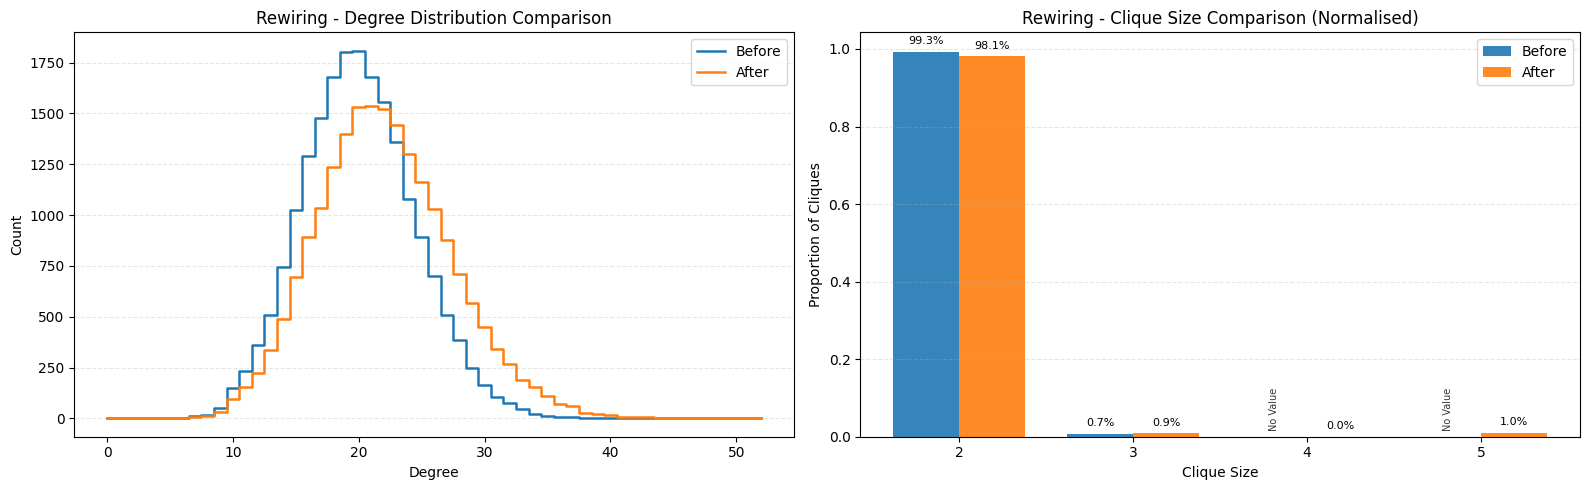

(np.True_,
 {'node_count': 20000,
  'target_clique_size': 5,
  'allowed_clique_sizes': [5, 4, 6, 3, 7],
  'degree_tolerance': 0.1,
  'original_avg_degree': 20.0247,
  'final_avg_degree': 22.027,
  'total_attempts': 202006,
  'successful_rewirings': 2005,
  'cache_hits': 0,
  'already_clique_groups': 0,
  'tolerance_rejections': 200001,
  'termination_reason': 'max_consecutive_failures'})

In [20]:
def run_single_network_simulation(
    num_nodes,
    kmean,
    clique_size,
    visualise=False,
    return_network=True,
    cleanup_after_run=False,
    print_summary=True,
):
    """
    Generate a connected ER graph, rewire it with cliques, and validate.

    @param num_nodes: Number of nodes in the generated graph.
    @param kmean: Target mean degree for the ER graph.
    @param clique_size: Target clique size passed to the rewirer.
    @param visualise: Print stats and show compact before/after plots when True.
    @param return_network: Keep and return the rewired graph when True.
    @param cleanup_after_run: Force cleanup before returning when True.
    @param print_summary: Print compact run stats when True.
    @return: Tuple containing validation result, optional network, and run stats.
    """
    generator = None
    ntwk = None
    before_ntwk = None
    original_degree_sequence = None
    rewirer = None
    run_stats = None
    try:
        generator = NetworkGenerator(num_nodes, kmean)
        ntwk = generator.generate_erdos_renyi_graph(require_connected=True)
        before_ntwk = ntwk.copy()
        original_degree_sequence = sorted([d for _, d in ntwk.degree()])

        rewirer = Rewirer(ntwk)
        ntwk = rewirer.rewire_network_cliques(clique_size, print_stats=visualise)
        model_valid = validate_er_network(ntwk, original_degree_sequence)
        run_stats = rewirer.get_last_run_stats()

        if visualise:
            before_avg = reporter.get_average_degree(before_ntwk)
            after_avg = reporter.get_average_degree(ntwk)
            print("Simulation state summary:")
            print(
                f"before: nodes={before_ntwk.number_of_nodes()}, edges={before_ntwk.number_of_edges()}, avg_degree={before_avg:.4f}"
            )
            print(
                f"after : nodes={ntwk.number_of_nodes()}, edges={ntwk.number_of_edges()}, avg_degree={after_avg:.4f}, valid={model_valid}"
            )
            reporter.visualise_before_after_comparison(
                before_ntwk,
                ntwk,
                title_prefix="Rewiring - ",
            )
        elif print_summary and run_stats is not None:
            print(
                "Run summary:",
                f"valid={model_valid}, attempts={run_stats['total_attempts']}, ",
                f"rewires={run_stats['successful_rewirings']}, ",
                f"termination={run_stats['termination_reason']}",
                sep=""
            )

        if cleanup_after_run and not return_network:
            ntwk = None
            before_ntwk = None
            _cleanup_simulation_state()

        if return_network:
            return model_valid, ntwk, run_stats
        return model_valid, run_stats
    finally:
        generator = None
        original_degree_sequence = None
        rewirer = None
        if cleanup_after_run and not return_network:
            ntwk = None
            before_ntwk = None
            run_stats = None
            gc.collect()


run_single_network_simulation(20000, rng.randint(5, 20), 5, visualise=True)


### How to know that the work done is valid? 
Given the scale and nature of the process, visually demonstrating the differences between the original network and the rewired network is challenging. Instead, the evaluation relies on behavioural indicators within the network’s structural properties.

For an Erdős–Rényi network, the degree distribution—when plotted as a histogram—should approximate a bell‑shaped curve. If the rewired network deviates significantly from this pattern, the rewiring process can be considered unsuccessful. A further check involves comparing the average degree of the rewired network with that of the original. This value should remain within 10% of the initial average degree. To streamline this step, an automated validation check is performed, and its result is displayed in the log once each simulation completes.

In addition to degree‑based validation, the bar chart showing clique count percentages should indicate a shift in the distribution of clique sizes, ideally reflecting an increase towards the target clique size. In some cases, the change may be modest; however, as long as there is clear evidence that the rewiring process has produced cliques close to the target size without causing excessive distortion to the degree distribution, the rewiring can be considered successful.

### Output from simulation 
In the original network, most cliques are of size 2, with a smaller number of size‑3 cliques. The rewiring process aims to increase as many of these size‑2 cliques as possible so that they fall closer to the target size of 5. On a machine with adequate resources, rewiring typically takes around 1–2 minutes.

After rewiring, we usually see a noticeable increase in cliques of the target size, along with a modest rise in nearby sizes. The algorithm tends to form cliques of size 5 and 3 more easily than size 4, which often proves more difficult. Despite these changes, the network still retains a majority of size‑2 cliques. Reducing them significantly would push the average degree distribution beyond acceptable limits, so only minor reductions are expected.

The rewiring process generally terminates because it reaches the maximum number of allowed failures, indicating that it cannot proceed further without violating one of the constraints outlined earlier.

### Conclusion
With this in mind, this single experiment should have demonstrated compliance with the requirements of the task and returned a valid rewired network with clique totals closer to the target value. 

## Step 4: Run Multiple Simulations

Now that it is possible to show that a random ER network can be rewired, lets try a number of different random networks with a slightly larger node range than what was used in the initial run. 

### Step 4.1 Run Multiple simulations within a 20-30k Node range

Running simulation 1/5
Simulation parameters: nodes=22906, kmean=14, clique_size=5
Rewiring stats:
  allowed clique sizes : [5, 4, 6, 3, 7]
  attempts            : 230666
  successful rewires  : 1606
  cache hits          : 0
  already-clique skips: 0
  tolerance rejections: 229060
  avg degree          : 14.0156 -> 15.4171
  stop reason         : max_consecutive_failures
Simulation state summary:
before: nodes=22906, edges=160521, avg_degree=14.0156
after : nodes=22906, edges=176572, avg_degree=15.4171, valid=True


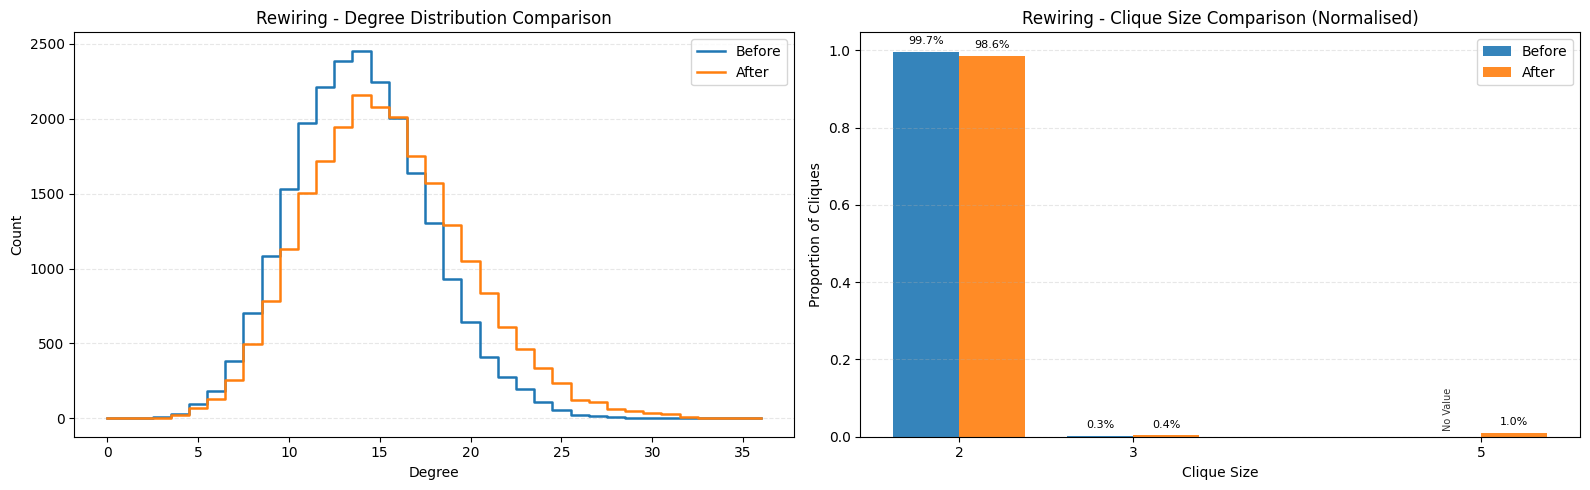

Simulation 1 valid: True
Batch summary:  rewires=1606,  attempts=230666,  termination=max_consecutive_failures
Simulation 1 complete - memory cleared.

Running simulation 2/5
Simulation parameters: nodes=24278, kmean=14, clique_size=5
Rewiring stats:
  allowed clique sizes : [5, 4, 6, 3, 7]
  attempts            : 244481
  successful rewires  : 1701
  cache hits          : 0
  already-clique skips: 0
  tolerance rejections: 242780
  avg degree          : 14.0084 -> 15.4091
  stop reason         : max_consecutive_failures
Simulation state summary:
before: nodes=24278, edges=170048, avg_degree=14.0084
after : nodes=24278, edges=187051, avg_degree=15.4091, valid=True


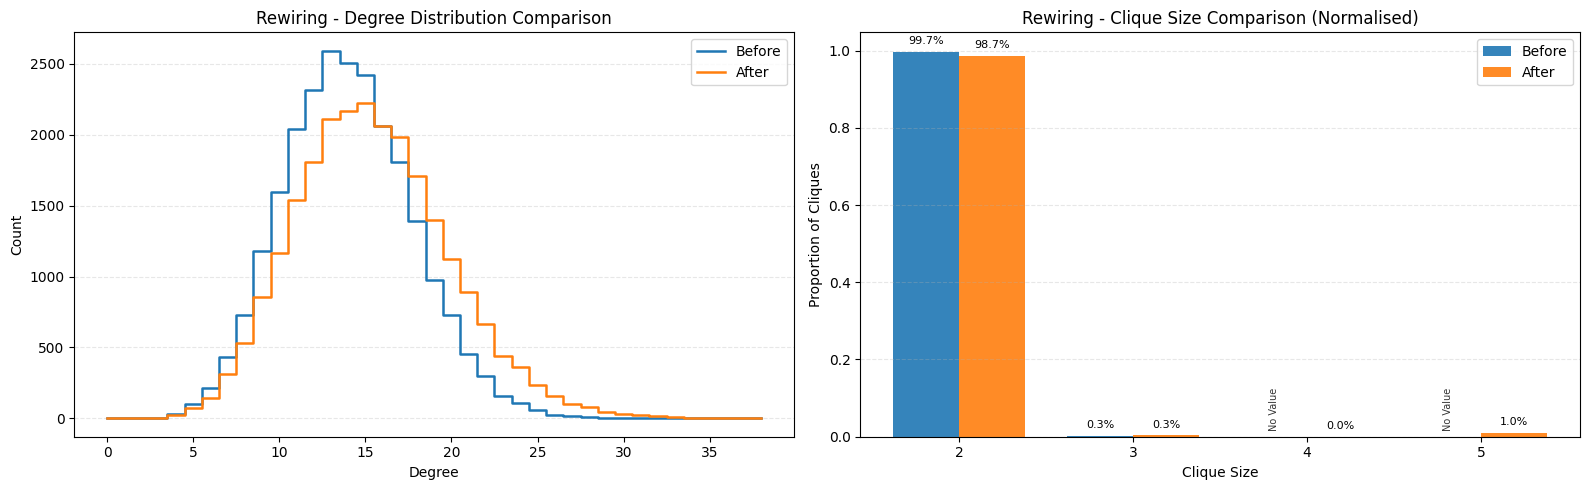

Simulation 2 valid: True
Batch summary:  rewires=1701,  attempts=244481,  termination=max_consecutive_failures
Simulation 2 complete - memory cleared.

Running simulation 3/5
Simulation parameters: nodes=22886, kmean=35, clique_size=5
Rewiring stats:
  allowed clique sizes : [5, 4, 6, 3, 7]
  attempts            : 234168
  successful rewires  : 4017
  cache hits          : 0
  already-clique skips: 0
  tolerance rejections: 230151
  avg degree          : 35.0218 -> 38.5240
  stop reason         : max_consecutive_failures
Simulation state summary:
before: nodes=22886, edges=400755, avg_degree=35.0218
after : nodes=22886, edges=440830, avg_degree=38.5240, valid=True


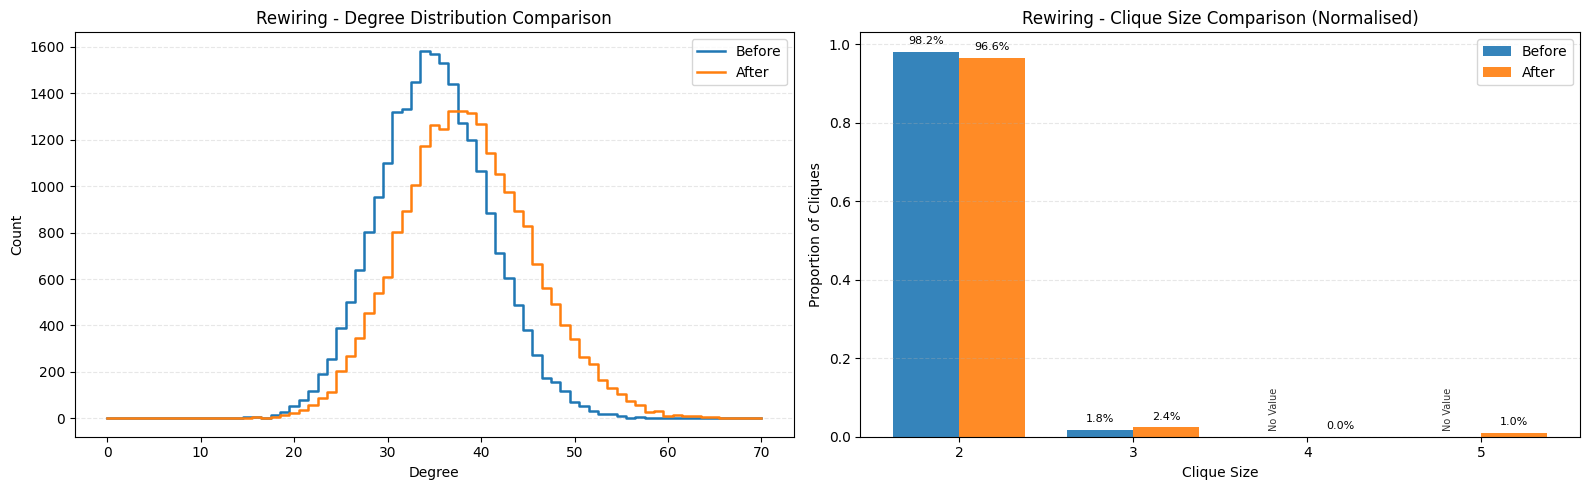

Simulation 3 valid: True
Batch summary:  rewires=4017,  attempts=234168,  termination=max_consecutive_failures
Simulation 3 complete - memory cleared.

Running simulation 4/5
Simulation parameters: nodes=22254, kmean=50, clique_size=5
Simulation 4 complete - memory cleared.



KeyboardInterrupt: 

In [21]:
def run_multiple_simulations(
    num_simulations,
    max_nodes,
    clique_size,
    visualise=False,
    print_summary=True,
):
    """
    Run several independent simulations, clearing memory between each run.

    @param num_simulations: Number of simulations to execute.
    @type  num_simulations: int
    @param max_nodes: Upper bound for the randomly chosen node count.
    @type  max_nodes: int
    @param clique_size: Target clique size passed to each simulation.
    @type  clique_size: int
    @param visualise: If True, print stats and plot distributions per run.
    @type  visualise: bool
    @param print_summary: Print compact stats for each run when True.
    @type  print_summary: bool
    """
    for i in range(num_simulations):
        model_valid = None
        run_stats = None
        print(f"Running simulation {i + 1}/{num_simulations}")
        try:
            node_count = rng.randint(20000, max_nodes)
            kmean = rng.randint(5, 50)
            print(
                f"Simulation parameters: nodes={node_count}, kmean={kmean}, clique_size={clique_size}"
            )
            model_valid, run_stats = run_single_network_simulation(
                node_count,
                kmean,
                clique_size,
                visualise=visualise,
                return_network=False,
                cleanup_after_run=False,
                print_summary=print_summary,
            )
            print(f"Simulation {i + 1} valid: {model_valid}")
            if run_stats is not None:
                print(
                    "Batch summary:",
                    f" rewires={run_stats['successful_rewirings']},",
                    f" attempts={run_stats['total_attempts']},",
                    f" termination={run_stats['termination_reason']}",
                )
        except ValueError:
            print("Simulation failed with current values, retrying")
            node_count = rng.randint(20000, max_nodes)
            kmean = rng.randint(5, 50)
            print(
                f"Retry parameters: nodes={node_count}, kmean={kmean}, clique_size={clique_size}"
            )
            model_valid, run_stats = run_single_network_simulation(
                node_count,
                kmean,
                clique_size,
                visualise=visualise,
                return_network=False,
                cleanup_after_run=False,
                print_summary=print_summary,
            )
            print(f"Simulation {i + 1} valid: {model_valid}")
            if run_stats is not None:
                print(
                    "Batch summary:",
                    f" rewires={run_stats['successful_rewirings']},",
                    f" attempts={run_stats['total_attempts']},",
                    f" termination={run_stats['termination_reason']}",
                )
        finally:
            model_valid = None
            run_stats = None
            _cleanup_simulation_state()
            print(f"Simulation {i + 1} complete - memory cleared.\n")


run_multiple_simulations(5, 30000, 5, visualise=True)

### Step 4.1.1 Conculsion
With this number of expanded number of nodes, we again see that the rewiring was able to make some changes in the clique counts, but not significantly as expected if we want to retain the degrees distribution. Due to the random formation of the network, we see that the occurance of a certain size of clique close to the desired target is not certainty. In some instances, it could be that some cliques of a particular value close to the target are never formed in a sigle network. 

### Step 4.2 Run Multiple simulations within a 20-40k Node range
**Note:** This may take some time (depending on the machine used) to complete.

In [ ]:
run_multiple_simulations(5, 40000, 5, visualise=True)

### Step 4.2.1 Conclusion 
As with Step 4.1, a similar behaviour pattern can be seen within the rewiring process with regards to clique counts and the stochastic nature of the totals. There may, however, be a reduced possibility that clique values close to the target are not formed in a single network. This is primarily down to the increased number of nodes enabling a greater chance of a given clique being able to form. Possibility being the key word here, as there is no guarantee in this with the random nature of ER network formation.

# Step 5: Future Improvements
Although the rewiring process meets the current requirements, several enhancements could improve performance, scalability, and overall effectiveness:

1. Parallel Processing  
At present, rewiring is entirely sequential: each node is processed one at a time, validated, and either accepted or reverted before moving on. Introducing parallel processing (e.g., multithreading) would allow multiple nodes to be evaluated simultaneously, provided appropriate locking mechanisms are used to prevent conflicts. This could significantly reduce runtime and enable the system to handle larger networks more efficiently.

2. Improved Rewiring Strategy  
The current approach operates on a “first come, first serve” basis, meaning nodes early in the sequence dominate the rewiring opportunities. If the degree distribution threshold is exceeded early, large portions of the network may never be considered. A randomised node‑selection strategy could broaden the search space, allowing the algorithm to explore more of the network and potentially form more cliques near the target size. This would reduce bias introduced by sequential processing and improve overall rewiring effectiveness.

# Step 6: Overall Conclusions
Across multiple simulations with varying network sizes, the same core behaviours observed in the single‑run example (see Step 4) were consistently reproduced. These repeated results demonstrate that the rewiring process is stable and reproducible.

In all experiments, a small but meaningful number of cliques were successfully formed at or near the target size, without causing major deviations in the average degree distribution. This confirms that the rewiring process meets the criteria outlined at the beginning of this document.

While the system performs effectively under the current design, there remains clear scope for improvement. The enhancements described above offer promising directions for future development and could further optimise the rewiring process.